In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

os.makedirs('models', exist_ok=True)
RANDOM_STATE = 42

In [7]:
# ── Chargement
df = pd.read_csv('../data/annonces_enrichies_int.csv', sep=';', low_memory=False)
print(f'Chargé : {len(df):,} lignes')

Chargé : 95,202 lignes


In [8]:
# ── Nettoyage de base 

mapping_type = {
    'appartement': 'Appartement', 'APPARTEMENT': 'Appartement',
    'studio':      'Studio',
    'maison':      'Maison',
}
df['type_bien'] = df['type_bien'].str.strip().replace(mapping_type)
df = df[df['type_bien'].notna()]

# Filtres de base (ton code original)
df = df[
    (df['loyer']    >= 250) & (df['loyer']   <= 10_000) &
    (df['surface']  >= 10)  & (df['surface'] <= 300)    &
    (df['loyer_m2_moyen'] > 0) &
    (df['nb_pieces'] > 0)
]

# Loyer/m² calculé — filtre les aberrations
df['loyer_m2_calc'] = df['loyer'] / df['surface']
df = df[df['loyer_m2_calc'].between(3, 100)]

print(f'Après nettoyage : {len(df):,} lignes')
print(df['type_bien'].value_counts())

Après nettoyage : 89,140 lignes
type_bien
Appartement    80070
Maison          4728
Studio          4342
Name: count, dtype: int64


In [9]:
# Ajouter les Nouvelles features
df['surface_par_piece'] = (df['surface'] / df['nb_pieces']).round(1)
df['log_surface']       = np.log1p(df['surface'])
df['est_idf']           = df['code_postal'].astype(str).str.startswith(
                             ('75','77','78','91','92','93','94','95')).astype(int)
df['est_paris']         = df['code_postal'].astype(str).str.startswith('75').astype(int)
df['type_encoded']      = df['type_bien'].map({'Appartement': 0, 'Studio': 1, 'Maison': 2})

# ── Liste des features (ton code avait 4 features, on passe à 9)
FEATURES = [
    'surface',           # m² du bien
    'log_surface',       # version log (capture mieux la relation non-linéaire)
    'nb_pieces',         # nombre de pièces
    'surface_par_piece', # surface moyenne par pièce
    'loyer_m2_moyen',    # prix moyen du m² dans la zone (feature la plus corrélée)
    'code_postal',       # localisation brute
    'est_idf',           # bonus IDF
    'est_paris',         # bonus Paris
    'type_encoded',      # type de bien
]
TARGET = 'loyer'

# Dataset ML — on retire les rares NaN restants
df_ml = df[FEATURES + [TARGET]].dropna()
print(f'Dataset ML : {len(df_ml):,} lignes × {len(FEATURES)} features')
print()

# Corrélations avec le loyer
corr = df_ml.corr()[TARGET].drop(TARGET).sort_values(ascending=False)
print('Corrélations avec le loyer :')
print(corr.round(3))

Dataset ML : 89,140 lignes × 9 features

Corrélations avec le loyer :
loyer_m2_moyen       0.584
surface              0.571
log_surface          0.491
est_paris            0.454
est_idf              0.448
nb_pieces            0.428
code_postal          0.237
surface_par_piece    0.190
type_encoded         0.084
Name: loyer, dtype: float64


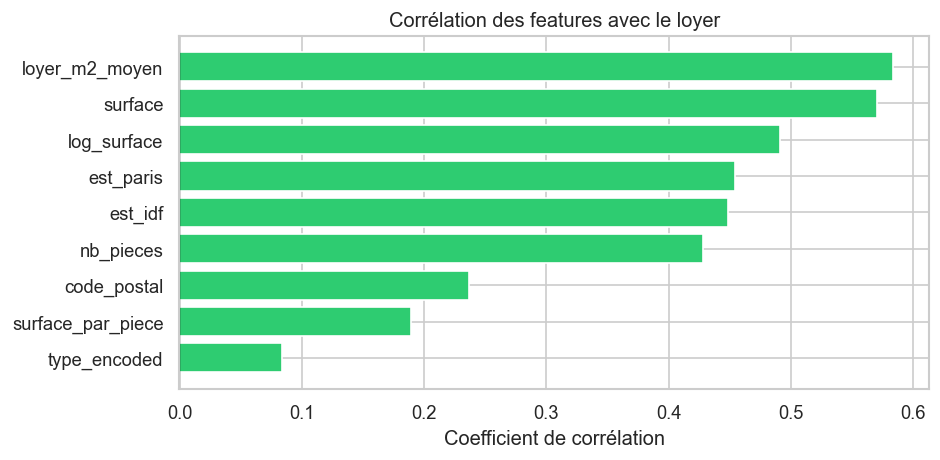

In [10]:
# Visualisation des corrélations
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr.values]
ax.barh(corr.index[::-1], corr.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Corrélation des features avec le loyer')
ax.set_xlabel('Coefficient de corrélation')
plt.tight_layout()
plt.savefig('models/correlations_features.png')
plt.show()

In [11]:
# Comparaison de 3 modèles suggeres 
#Ridge  _ Random Forest   _ Gradient Boosting 

In [12]:
X = df_ml[FEATURES]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train : {len(X_train):,} lignes')
print(f'Test  : {len(X_test):,} lignes')
print(f'Loyer moyen train : {y_train.mean():.0f} €')
print(f'Loyer moyen test  : {y_test.mean():.0f} €')

Train : 71,312 lignes
Test  : 17,828 lignes
Loyer moyen train : 957 €
Loyer moyen test  : 951 €


In [13]:
# ── Définition des 3 modèles
modeles = {
    'Ridge (baseline)': Ridge(alpha=10),
    'Random Forest':    RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                                    max_depth=5, random_state=RANDOM_STATE),
}

# ── Entraînement et évaluation
resultats = []
predictions = {}

for nom, modele in modeles.items():
    print(f' Entraînement : {nom}...')
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    predictions[nom] = y_pred

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # erreur relative %

    resultats.append({'Modèle': nom, 'MAE (€)': mae, 'RMSE (€)': rmse, 'R²': r2, 'MAPE (%)': mape})
    print(f'   MAE={mae:.0f} €  |  RMSE={rmse:.0f} €  |  R²={r2:.4f}  |  MAPE={mape:.1f}%')

df_res = pd.DataFrame(resultats).set_index('Modèle').round(2)
print()
print('━━ RÉSUMÉ ━━')
display(df_res.style.highlight_min(subset=['MAE (€)', 'RMSE (€)', 'MAPE (%)'], color='#c8f7c5')
                     .highlight_max(subset=['R²'], color='#c8f7c5'))

 Entraînement : Ridge (baseline)...
   MAE=237 €  |  RMSE=413 €  |  R²=0.6934  |  MAPE=27.9%
 Entraînement : Random Forest...
   MAE=148 €  |  RMSE=284 €  |  R²=0.8551  |  MAPE=15.9%
 Entraînement : Gradient Boosting...
   MAE=152 €  |  RMSE=282 €  |  R²=0.8572  |  MAPE=16.4%

━━ RÉSUMÉ ━━


,MAE (€),RMSE (€),R²,MAPE (%)
Modèle,,,,
Ridge (baseline),237.150000,413.490000,0.690000,27.870000
Random Forest,147.910000,284.270000,0.860000,15.920000
Gradient Boosting,152.330000,282.160000,0.860000,16.370000


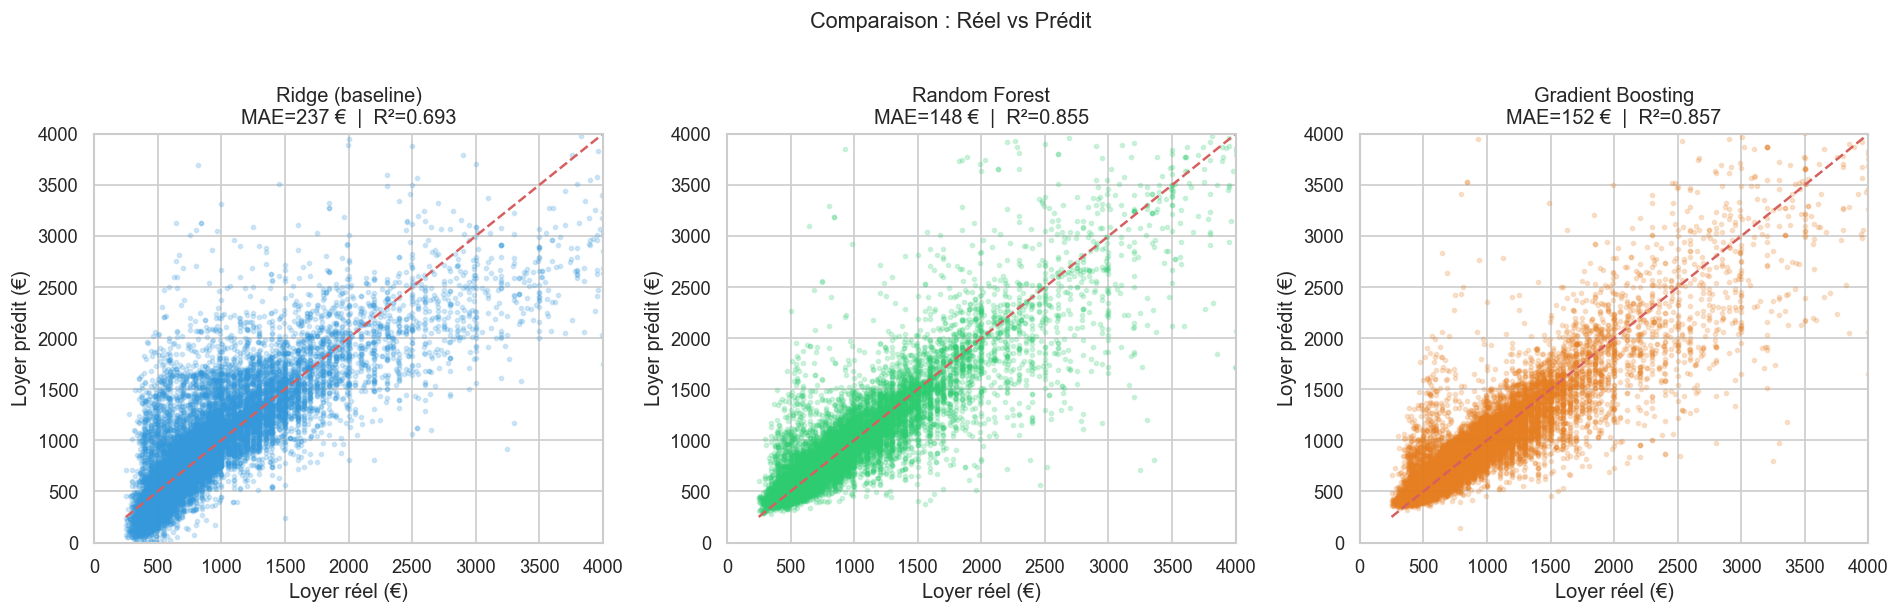

In [11]:
# Visualisation comparative : réel vs prédit pour les 3 modèles
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_mod = ['#3498db', '#2ecc71', '#e67e22']

for ax, (nom, y_pred), color in zip(axes, predictions.items(), colors_mod):
    ax.scatter(y_test, y_pred, alpha=0.2, s=6, color=color)
    lim = [y.min(), min(y.max(), 5000)]
    ax.plot(lim, lim, 'r--', lw=1.5)
    mae = mean_absolute_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    ax.set_title(f'{nom}\nMAE={mae:.0f} €  |  R²={r2:.3f}')
    ax.set_xlabel('Loyer réel (€)')
    ax.set_ylabel('Loyer prédit (€)')
    ax.set_xlim(0, 4000)
    ax.set_ylim(0, 4000)

plt.suptitle('Comparaison : Réel vs Prédit', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('models/comparaison_modeles.png', bbox_inches='tight')
plt.show()

In [14]:
## 4. Optimisation du meilleur modèle (Random Forest)

In [15]:
print(' Entraînement du modèle final optimisé...')

model_final = RandomForestRegressor(
    n_estimators=300,     
    max_depth=20,         # limite la profondeur pour réduire l'overfitting
    min_samples_leaf=5,   # chaque feuille doit avoir au moins 5 observations
    max_features='sqrt',  # nombre de features par split (sqrt = recommandé)
    random_state=RANDOM_STATE,
    n_jobs=-1
)
model_final.fit(X_train, y_train)
y_pred_final = model_final.predict(X_test)

mae_f  = mean_absolute_error(y_test, y_pred_final)
rmse_f = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_f   = r2_score(y_test, y_pred_final)
mape_f = np.mean(np.abs((y_test - y_pred_final) / y_test)) * 100

print(f'\n Modèle final :  MAE={mae_f:.0f} €  |  RMSE={rmse_f:.0f} €  |  R²={r2_f:.4f}  |  MAPE={mape_f:.1f}%')

# Cross-validation 5 folds
print('\n Cross-validation 5 folds (R²)...')
cv_scores = cross_val_score(model_final, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f'   R² par fold : {cv_scores.round(4)}')
print(f'   R² moyen    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

 Entraînement du modèle final optimisé...

 Modèle final :  MAE=151 €  |  RMSE=283 €  |  R²=0.8562  |  MAPE=16.2%

 Cross-validation 5 folds (R²)...
   R² par fold : [0.8416 0.8222 0.738  0.752  0.8458]
   R² moyen    : 0.7999 ± 0.0458


## 5. Analyse des erreurs

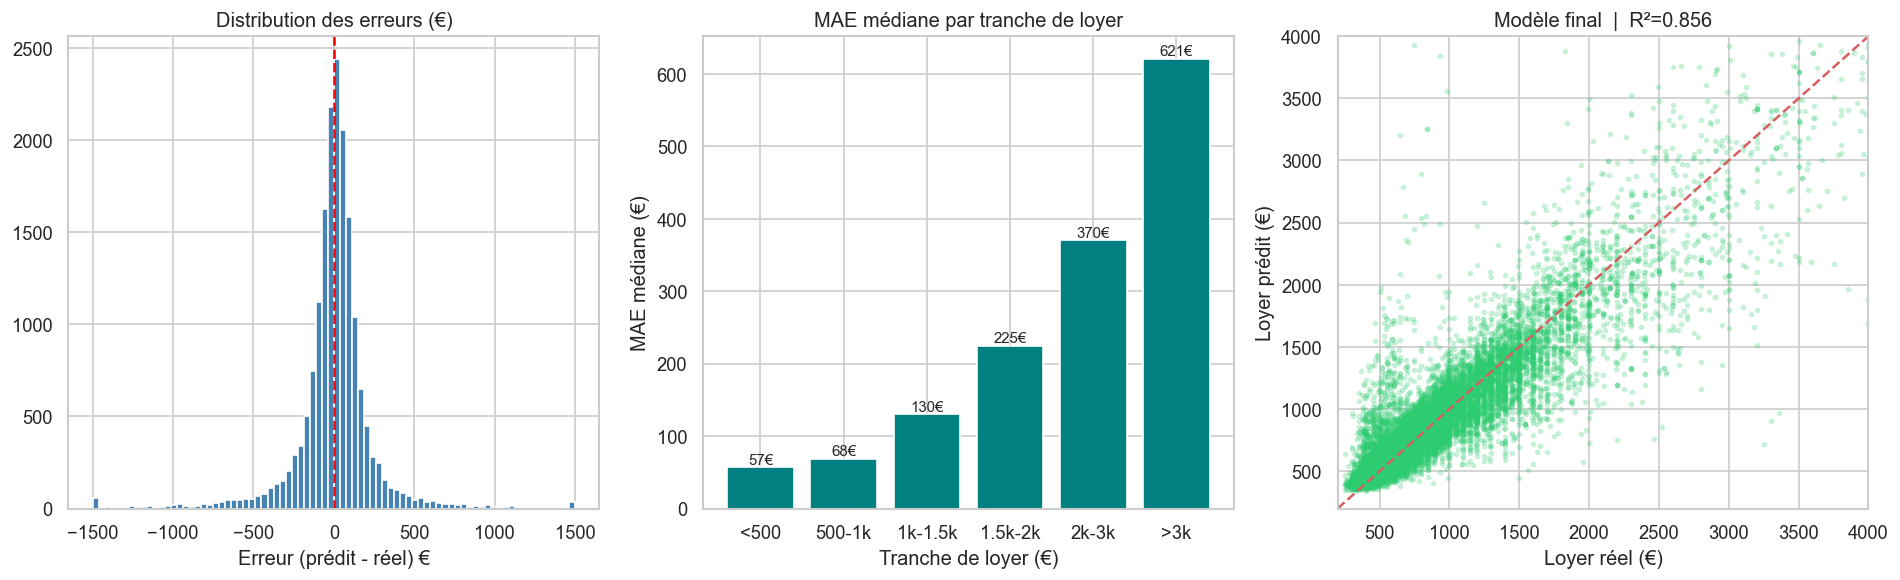

Erreur médiane : 12 €  (biais du modèle)
90% des prédictions sont dans ±335 €


In [14]:
df_err = X_test.copy()
df_err['loyer_reel']  = y_test.values
df_err['loyer_predit'] = y_pred_final
df_err['erreur']       = y_pred_final - y_test.values
df_err['erreur_abs']   = np.abs(df_err['erreur'])
df_err['erreur_pct']   = (df_err['erreur'] / df_err['loyer_reel'] * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution des erreurs
axes[0].hist(df_err['erreur'].clip(-1500, 1500), bins=80, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Distribution des erreurs (€)')
axes[0].set_xlabel('Erreur (prédit - réel) €')

# Erreur absolue par tranche de loyer réel
df_err['tranche'] = pd.cut(df_err['loyer_reel'], bins=[0,500,1000,1500,2000,3000,10000],
                            labels=['<500','500-1k','1k-1.5k','1.5k-2k','2k-3k','>3k'])
err_par_tranche = df_err.groupby('tranche')['erreur_abs'].median()
axes[1].bar(err_par_tranche.index, err_par_tranche.values, color='teal')
axes[1].set_title('MAE médiane par tranche de loyer')
axes[1].set_xlabel('Tranche de loyer (€)')
axes[1].set_ylabel('MAE médiane (€)')
for i, v in enumerate(err_par_tranche.values):
    axes[1].text(i, v+5, f'{v:.0f}€', ha='center', fontsize=9)

# Réel vs Prédit final
axes[2].scatter(df_err['loyer_reel'], df_err['loyer_predit'], alpha=0.2, s=6, color='#2ecc71')
lim = [200, 4000]
axes[2].plot(lim, lim, 'r--', lw=1.5)
axes[2].set_xlim(*lim); axes[2].set_ylim(*lim)
axes[2].set_title(f'Modèle final  |  R²={r2_f:.3f}')
axes[2].set_xlabel('Loyer réel (€)')
axes[2].set_ylabel('Loyer prédit (€)')

plt.tight_layout()
plt.savefig('models/analyse_erreurs.png', bbox_inches='tight')
plt.show()

print(f'Erreur médiane : {df_err["erreur"].median():.0f} €  (biais du modèle)')
print(f'90% des prédictions sont dans ±{df_err["erreur_abs"].quantile(0.9):.0f} €')

## 6. Importance des features

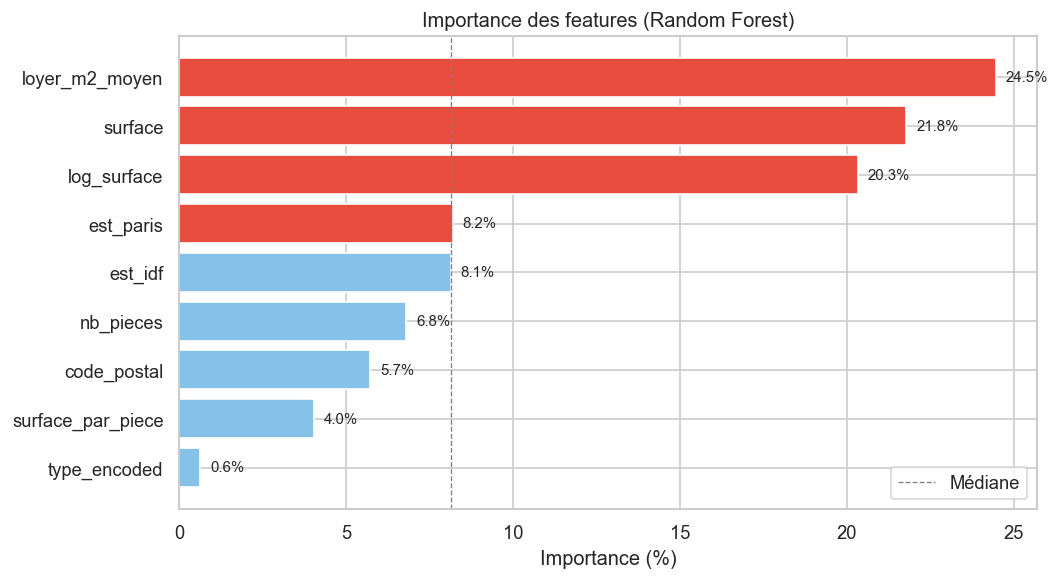


Top 3 features les plus importantes :
  loyer_m2_moyen         → 24.5%
  surface                → 21.8%
  log_surface            → 20.3%


In [15]:
importances = pd.Series(model_final.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if v > importances.median() else '#85c1e9' for v in importances.values]
bars = ax.barh(importances.index, importances.values * 100, color=colors)

for bar, val in zip(bars, importances.values * 100):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_title('Importance des features (Random Forest)')
ax.set_xlabel('Importance (%)')
ax.axvline(importances.median() * 100, color='gray', linestyle='--', linewidth=0.8,
           label='Médiane')
ax.legend()
plt.tight_layout()
plt.savefig('models/importance_features.png')
plt.show()

print('\nTop 3 features les plus importantes :')
for f, v in importances.sort_values(ascending=False).head(3).items():
    print(f'  {f:<22} → {v*100:.1f}%')

In [17]:
# ── Sauvegarde du modèle
joblib.dump(model_final, 'models/model_loyer.pkl')
print(' Modèle sauvegardé : models/model_loyer.pkl')

# ── Sauvegarde de la liste des features
with open('models/features.json', 'w') as f:
    json.dump(FEATURES, f, indent=2)
print(' Features sauvegardées : models/features.json')

# ── Métriques exportées
metriques = {
    'mae':  round(mae_f, 2),
    'rmse': round(rmse_f, 2),
    'r2':   round(r2_f, 4),
    'mape': round(mape_f, 2),
    'nb_train': len(X_train),
    'nb_test':  len(X_test),
    'features': FEATURES,
}
with open('models/metriques.json', 'w') as f:
    json.dump(metriques, f, indent=2, ensure_ascii=False)
print('Métriques sauvegardées : models/metriques.json')

for f in os.listdir('models'):
    path = os.path.join('models', f)
    size = os.path.getsize(path) / 1024
    print(f'  {f:<40} {size:>8.1f} Ko')

 Modèle sauvegardé : models/model_loyer.pkl
 Features sauvegardées : models/features.json
Métriques sauvegardées : models/metriques.json
  correlations_features.png                    38.4 Ko
  features.json                                 0.2 Ko
  features_enriched.json                        0.1 Ko
  metriques.json                                0.3 Ko
  model_loyer.pkl                          218117.0 Ko
  model_loyer_enriched.pkl                 755011.3 Ko


In [17]:
# ── Fonction de prédiction réutilisable

def predict_loyer(surface, nb_pieces, loyer_m2_moyen, code_postal,
                  type_bien='Appartement',
                  model_path='models/model_loyer.pkl',
                  features_path='models/features.json'):
    model    = joblib.load(model_path)
    features = json.load(open(features_path))

    type_map = {'Appartement': 0, 'Studio': 1, 'Maison': 2}
    cp_str   = str(code_postal)

    row = {
        'surface':           surface,
        'log_surface':       np.log1p(surface),
        'nb_pieces':         nb_pieces,
        'surface_par_piece': round(surface / nb_pieces, 1) if nb_pieces > 0 else surface,
        'loyer_m2_moyen':    loyer_m2_moyen,
        'code_postal':       code_postal,
        'est_idf':           int(cp_str.startswith(('75','77','78','91','92','93','94','95'))),
        'est_paris':         int(cp_str.startswith('75')),
        'type_encoded':      type_map.get(type_bien, 0),
    }

    X_input = pd.DataFrame([row])[features]
    loyer   = model.predict(X_input)[0]

    # Intervalle de confiance approximatif (±15%)
    margin = loyer * 0.15

    return {
        'loyer_estime':    round(loyer, 0),
        'intervalle_bas':  round(loyer - margin, 0),
        'intervalle_haut': round(loyer + margin, 0),
        'loyer_m2_estime': round(loyer / surface, 1),
    }


# ── Test immédiat
print('Exemples de prédictions :')
print()
cas_tests = [
    dict(surface=45, nb_pieces=2, loyer_m2_moyen=28, code_postal=75011, type_bien='Appartement'),
    dict(surface=22, nb_pieces=1, loyer_m2_moyen=32, code_postal=75016, type_bien='Studio'),
    dict(surface=90, nb_pieces=4, loyer_m2_moyen=15, code_postal=69003, type_bien='Maison'),
]
for cas in cas_tests:
    res = predict_loyer(**cas)
    print(f"  {cas['surface']}m² {cas['type_bien']} {cas['code_postal']}")
    print(f"  → {res['loyer_estime']:.0f} € [{res['intervalle_bas']:.0f} – {res['intervalle_haut']:.0f} €]  ({res['loyer_m2_estime']} €/m²)")
    print()

Exemples de prédictions :

  45m² Appartement 75011
  → 1414 € [1202 – 1626 €]  (31.4 €/m²)

  22m² Studio 75016
  → 927 € [788 – 1066 €]  (42.1 €/m²)

  90m² Maison 69003
  → 1086 € [923 – 1249 €]  (12.1 €/m²)

